# UE Data Mining - Projet

## Data Cleaning : Ecology

In [2]:
import pandas as pd
import re
df_bats = pd.read_csv('data/ecology/bat_surveys.csv')
df_env_field = pd.read_csv('data/ecology/environmental_field_reports.csv')
df_env_monthly = pd.read_csv('data/ecology/environmental_monthly.csv')
df_monitor_dev = pd.read_csv('data/ecology/monitoring_device_operations.csv')
df_monitor_sites = pd.read_csv('data/ecology/monitoring_sites.csv')
df_orchard = pd.read_csv('data/ecology/orchard_surveys.csv')

#### bat_surveys
    Describe pour observer les données
    Enleve les doublons
    Remplace les noms des observer team comme "unknown"

In [3]:
df_bats.describe()

,colony_estimate,comparison_species_count
count,4994.000000,4994.000000
mean,15.826512,10.711854
std,9.603602,3.449512
min,0.000000,1.000000
25%,9.300000,8.000000
50%,14.200000,11.000000
75%,20.500000,13.000000
max,99.600000,26.000000


In [4]:
print(df_bats.duplicated().sum())
df_bats = df_bats.drop_duplicates()

2


In [5]:
print(df_bats.isna().sum())
df_bats['observer_team'] = df_bats['observer_team'].fillna('unknown')

survey_id                    0
site_code                    0
survey_start                 0
survey_end                   0
survey_method                0
observation_hours            0
observed_bat_count           0
acoustic_detection_count     0
nightly_visit_count          0
colony_estimate              0
comparison_species_count     0
observer_team               20
survey_quality               0
weather_interference         0
dtype: int64


    On observe problèmes de generalisation de dates, de ponctuations (floats), de majuscules etc
    On a aussi la survey_quality à mettre en 2 ou 3 colonnes

In [6]:
for c in df_bats:
    print(df_bats[c].value_counts())


survey_id
BAT-0000001    1
BAT-0000002    1
BAT-0000003    1
BAT-0000004    1
BAT-0000005    1
              ..
BAT-0004988    1
BAT-0004989    1
BAT-0004990    1
BAT-0004991    1
BAT-0004992    1
Name: count, Length: 4992, dtype: int64
site_code
KNT-KES    78
KNT-LUM    78
KNT-SEN    78
AVL-MAR    78
AVL-VEL    78
           ..
TMB-WST    78
TMB-SXP    78
TMB-WQL    78
TMB-QCB    78
TMB-DLQ    78
Name: count, Length: 64, dtype: int64
survey_start
2019-01-05T18:00:00    64
2019-02-05T18:00:00    64
2019-03-05T18:00:00    64
2019-04-05T18:00:00    64
2019-05-05T18:00:00    64
                       ..
2025-02-05T18:00:00    64
2025-03-05T18:00:00    64
2025-04-05T18:00:00    64
2025-05-05T18:00:00    64
2025-06-05T18:00:00    64
Name: count, Length: 78, dtype: int64
survey_end
2019-01-12T00:00:00     64
2019-03-12T00:00:00     64
2019-05-12T00:00:00     64
2019-06-12T00:00:00     64
2019-07-12T00:00:00     64
                        ..
12/07/2021 00:00:00      1
12-Apr-2019 00:00:00    

In [7]:
def clean_numeric(val):
    if pd.isna(val):
        return None
    s = str(val).strip()
    s = re.sub(r'[^\d,.\-]', '', s)
    # on enleve les lettres
    s = s.replace(',', '.')
    # on remplace les virgules
    try:
        return float(s)
    except ValueError:
        print(s)
        return None
for c in ["observation_hours","observed_bat_count","acoustic_detection_count","nightly_visit_count","colony_estimate","comparison_species_count","weather_interference"]:
    df_bats[c] = df_bats[c].apply(clean_numeric)
print(df_bats)

        survey_id site_code         survey_start           survey_end  \
0     BAT-0000001   KNT-KES  2019-01-05T18:00:00  2019-01-12T00:00:00   
1     BAT-0000002   KNT-KES  2019-02-05T18:00:00  2019-02-12T00:00:00   
2     BAT-0000003   KNT-KES  2019-03-05T18:00:00  2019-03-12T00:00:00   
3     BAT-0000004   KNT-KES  2019-04-05T18:00:00  2019-04-12T00:00:00   
4     BAT-0000005   KNT-KES  2019-05-05T18:00:00  2019-05-12T00:00:00   
...           ...       ...                  ...                  ...   
4987  BAT-0004988   TMB-DLQ  2025-02-05T18:00:00  2025-02-12T00:00:00   
4988  BAT-0004989   TMB-DLQ  2025-03-05T18:00:00  2025-03-12T00:00:00   
4989  BAT-0004990   TMB-DLQ  2025-04-05T18:00:00  2025-04-12T00:00:00   
4990  BAT-0004991   TMB-DLQ  2025-05-05T18:00:00  2025-05-12T00:00:00   
4991  BAT-0004992   TMB-DLQ  2025-06-05T18:00:00  2025-06-12T00:00:00   

               survey_method  observation_hours  observed_bat_count  \
0     fixed_acoustic_station               28.6     

In [8]:
df_bats["survey_method"] = df_bats['survey_method'].str.lower().str.strip()
df_bats["survey_end"] = pd.to_datetime(
    df_bats["survey_end"],
    format="mixed",
    errors="coerce"
)
df_bats['survey_end'] = df_bats['survey_end'].dt.strftime('%Y-%m-%dT%H:%M:%S')

print(df_bats["survey_end"].isna().sum())
df_bats['survey_end'].unique()

0


<StringArray>
['2019-01-12T00:00:00', '2019-02-12T00:00:00', '2019-03-12T00:00:00',
 '2019-04-12T00:00:00', '2019-05-12T00:00:00', '2019-06-12T00:00:00',
 '2019-07-12T00:00:00', '2019-08-12T00:00:00', '2019-09-12T00:00:00',
 '2019-10-12T00:00:00', '2019-11-12T00:00:00', '2019-12-12T00:00:00',
 '2020-01-12T00:00:00', '2020-02-12T00:00:00', '2020-03-12T00:00:00',
 '2020-04-12T00:00:00', '2020-05-12T00:00:00', '2020-06-12T00:00:00',
 '2020-07-12T00:00:00', '2020-08-12T00:00:00', '2020-09-12T00:00:00',
 '2020-10-12T00:00:00', '2020-11-12T00:00:00', '2020-12-12T00:00:00',
 '2021-01-12T00:00:00', '2021-02-12T00:00:00', '2021-03-12T00:00:00',
 '2021-04-12T00:00:00', '2021-05-12T00:00:00', '2021-06-12T00:00:00',
 '2021-07-12T00:00:00', '2021-08-12T00:00:00', '2021-09-12T00:00:00',
 '2021-10-12T00:00:00', '2021-11-12T00:00:00', '2021-12-12T00:00:00',
 '2022-01-12T00:00:00', '2022-02-12T00:00:00', '2022-03-12T00:00:00',
 '2022-04-12T00:00:00', '2022-05-12T00:00:00', '2022-06-12T00:00:00',
 '2022

    On créé 3 catégories à partir de survey_quality
    On garde la colonne survey_quality

In [9]:
dummies = pd.get_dummies(df_bats['survey_quality'], prefix='survey_quality')
df_bats = pd.concat([df_bats, dummies], axis=1)

In [10]:
for c in df_bats:
    print(df_bats[c].value_counts())

survey_id
BAT-0000001    1
BAT-0000002    1
BAT-0000003    1
BAT-0000004    1
BAT-0000005    1
              ..
BAT-0004988    1
BAT-0004989    1
BAT-0004990    1
BAT-0004991    1
BAT-0004992    1
Name: count, Length: 4992, dtype: int64
site_code
KNT-KES    78
KNT-LUM    78
KNT-SEN    78
AVL-MAR    78
AVL-VEL    78
           ..
TMB-WST    78
TMB-SXP    78
TMB-WQL    78
TMB-QCB    78
TMB-DLQ    78
Name: count, Length: 64, dtype: int64
survey_start
2019-01-05T18:00:00    64
2019-02-05T18:00:00    64
2019-03-05T18:00:00    64
2019-04-05T18:00:00    64
2019-05-05T18:00:00    64
                       ..
2025-02-05T18:00:00    64
2025-03-05T18:00:00    64
2025-04-05T18:00:00    64
2025-05-05T18:00:00    64
2025-06-05T18:00:00    64
Name: count, Length: 78, dtype: int64
survey_end
2019-01-12T00:00:00    64
2019-02-12T00:00:00    64
2019-03-12T00:00:00    64
2019-04-12T00:00:00    64
2019-05-12T00:00:00    64
                       ..
2025-06-12T00:00:00    63
2022-12-01T00:00:00     1
2020-

## env_field
    On remplace un nom manquant dans author_name comme "unknown"

In [11]:
print(df_env_field.isna().sum())
df_env_field['author_name'] = df_env_field['author_name'].fillna('unknown')

document_id                 0
site_code                   0
document_date               0
document_type               0
author_name                 1
author_organization         0
reporting_period            0
title                       0
text                        0
related_survey_id           0
related_device_reference    0
publication_status          0
dtype: int64


## env_monthly

In [12]:
df_env_monthly.describe()

,vegetation_cover_pct,habitat_disturbance_index,pesticide_index,data_completeness_pct
count,4984.000000,4994.000000,4979.00000,4994.000000
mean,61.021007,30.361494,25.01894,95.961854
std,13.998433,16.355488,16.26415,2.818489
min,15.000000,0.000000,0.00000,85.500000
25%,52.700000,17.900000,11.60000,94.000000
50%,62.300000,29.400000,25.20000,96.150000
75%,71.000000,41.400000,37.50000,98.200000
max,98.000000,86.800000,77.30000,100.000000


    On enlève les lignes doublons (il y en a 2 les mêmes que bats_survey)
    On remarque dans describe que 3 colonnes n'ont pas été traitées donc pas uniformisées


In [13]:
print(df_env_monthly.duplicated())
df_env_monthly = df_env_monthly.drop_duplicates()

0       False
1       False
2       False
3       False
4       False
        ...  
4989    False
4990    False
4991    False
4992     True
4993     True
Length: 4994, dtype: bool


In [14]:
for c in ["mean_temperature_c","rainfall_mm","mean_humidity_pct"]:
    df_env_monthly[c] = df_env_monthly[c].apply(clean_numeric)

df_env_monthly.describe()

,mean_temperature_c,rainfall_mm,mean_humidity_pct,vegetation_cover_pct,habitat_disturbance_index,pesticide_index,data_completeness_pct
count,4992.000000,4992.000000,4992.000000,4982.000000,4992.000000,4977.000000,4992.000000
mean,26.377073,159.894030,75.841847,61.014211,30.364423,25.016395,95.961819
std,1.672062,74.901939,7.248342,13.997015,16.358109,16.266360,2.817944
min,21.300000,5.000000,56.700000,15.000000,0.000000,0.000000,85.500000
25%,25.190000,95.700000,70.300000,52.700000,17.900000,11.600000,94.000000
50%,26.350000,156.250000,75.900000,62.300000,29.400000,25.200000,96.150000
75%,27.612500,221.700000,81.500000,70.900000,41.400000,37.500000,98.200000
max,32.000000,384.300000,96.400000,98.000000,86.800000,77.300000,100.000000


In [15]:
df_env_monthly.dropna(subset=["vegetation_cover_pct","pesticide_index"] ,inplace=True)
print( df_env_monthly.isna().sum())

site_code                       0
reporting_month                 0
mean_temperature_c              0
rainfall_mm                     0
mean_humidity_pct               0
vegetation_cover_pct            0
habitat_disturbance_index       0
pesticide_index                 0
land_use_category               0
weather_exception_code       4766
data_completeness_pct           0
dtype: int64


    On créé 2 catégories à partir de weather_exception_code
    On garde la colonne weather_exception_code

In [16]:
df_env_monthly["weather_exception_code"].value_counts()
dummies = pd.get_dummies(df_env_monthly['weather_exception_code'],
                         prefix='weather_exception_code')
df_env_monthly = pd.concat([df_env_monthly, dummies], axis=1)

## Monitoring device operations

In [17]:
df_monitor_dev["uptime_pct"] = df_monitor_dev["uptime_pct"].apply(clean_numeric)
df_monitor_dev = df_monitor_dev.drop_duplicates()

In [18]:
df_monitor_dev.describe()

,uptime_pct,acoustic_quality
count,4992.000000,4992.000000
mean,92.525962,78.992448
std,7.926554,8.506378
min,23.100000,20.000000
25%,90.200000,73.900000
50%,93.800000,79.300000
75%,97.300000,84.625000
max,100.000000,100.000000


In [19]:
df_monitor_dev["fault_code"].value_counts()
dummies = pd.get_dummies(df_monitor_dev['fault_code'],
                         prefix='fault_code')
df_monitor_dev = pd.concat([df_monitor_dev, dummies], axis=1)

## Monitoring sites

In [20]:
df_monitor_sites = df_monitor_sites.drop_duplicates()
df_monitor_sites = df_monitor_sites.drop(columns="programme_end_date")


In [21]:
# On créé 2 catégories à partir de cave_access_category
df_monitor_sites["cave_access_category"].value_counts()
dummies = pd.get_dummies(df_monitor_sites['cave_access_category'],
                         prefix='cave_access_category')
df_monitor_sites = pd.concat([df_monitor_sites, dummies], axis=1)
# On créé 2 catégories à partir de orchard_context
df_monitor_sites["orchard_context"].value_counts()
dummies = pd.get_dummies(df_monitor_sites['orchard_context'],
                         prefix='orchard_context')
df_monitor_sites = pd.concat([df_monitor_sites, dummies], axis=1)
# On pourrait le faire aussi pour habitat category

In [22]:
for c in df_monitor_sites:
    print(df_monitor_sites[c].value_counts())

site_code
KNT-KES    1
KNT-LUM    1
KNT-SEN    1
AVL-MAR    1
AVL-VEL    1
          ..
TMB-WST    1
TMB-SXP    1
TMB-WQL    1
TMB-QCB    1
TMB-DLQ    1
Name: count, Length: 64, dtype: int64
site_name
Kestrel Cavern Monitoring Site    1
Luma Karst Reserve Site           1
Senna Ridge Cave Site             1
Marula East Orchard Site          1
Velin Basin Orchard Site          1
                                 ..
Garnet Valley Monitoring Site     1
Juniper Grove Monitoring Site     1
Mango Coast Monitoring Site       1
Pandan Ridge Monitoring Site      1
Sable Forest Monitoring Site      1
Name: count, Length: 64, dtype: int64
site_category
habitat monitoring    40
orchard monitoring    15
cave monitoring        8
ORCHARD MONITORING     1
Name: count, dtype: int64
region
Kintara Karst Cluster                   22
Eastern Avelora Agricultural Cluster    22
Tembara Coastal Cluster                 20
Name: count, dtype: int64
jurisdiction
Kintara Republic        22
Avelora Federation     

## Orchard surveys

In [23]:
df_orchard = df_orchard.drop_duplicates()

In [24]:
# On créé des catégories à partir de agricultural_disturbance_note
df_orchard["agricultural_disturbance_note"].value_counts()
dummies = pd.get_dummies(df_orchard['agricultural_disturbance_note'],
                         prefix='agricultural_disturbance_note')
df_orchard = pd.concat([df_orchard, dummies], axis=1)

In [25]:
df_orchard.describe()

,fruit_set_rate_pct,other_pollinator_activity,irrigation_level
count,1248.000000,1248.000000,1248.000000
mean,53.199534,59.444551,39.966346
std,10.219081,9.374031,9.122503
min,0.467000,27.900000,11.500000
25%,46.900000,53.300000,33.800000
50%,52.800000,59.500000,39.500000
75%,59.400000,65.700000,45.500000
max,87.700000,93.700000,81.000000


In [26]:
for c in "orchard_area_ha","durian_yield_kg","durian_flower_density","fertilizer_use_index":
    df_orchard[c] = df_orchard[c].apply(clean_numeric)

In [27]:
for c in df_orchard:
    print(df_orchard[c].value_counts())

orchard_survey_id
ORC-0000001    1
ORC-0000002    1
ORC-0000003    1
ORC-0000004    1
ORC-0000005    1
              ..
ORC-0001244    1
ORC-0001245    1
ORC-0001246    1
ORC-0001247    1
ORC-0001248    1
Name: count, Length: 1248, dtype: int64
site_code
AVL-MAR    78
AVL-VEL    78
AVL-ORR    78
AVL-TRP    78
AVL-NFR    78
AVL-GRB    78
AVL-ECJ    78
AVL-RBC    78
AVL-KAR    78
AVL-YAU    78
AVL-HUA    78
AVL-NMQ    78
AVL-FNQ    78
TMB-BRC    78
TMB-SKZ    78
TMB-HQL    78
Name: count, dtype: int64
survey_period
2019-01-01    16
2019-02-01    16
2019-03-01    16
2019-04-01    16
2019-05-01    16
              ..
2025-02-01    16
2025-03-01    16
2025-04-01    16
2025-05-01    16
2025-06-01    16
Name: count, Length: 78, dtype: int64
orchard_area_ha
24.1    78
62.3    78
59.7    78
54.7    78
24.4    78
54.4    78
60.9    78
59.2    78
84.7    78
6.0     78
47.7    78
31.3    78
38.2    78
25.7    78
51.0    78
44.2    78
Name: count, dtype: int64
durian_flower_density
100.0    99
50.6

In [28]:
from pathlib import Path

output_dir = Path("data_cleaned/ecology")
output_dir.mkdir(parents=True, exist_ok=True)

datasets = {
    "bats_surveys_clean.csv": df_bats,
    "environmental_field_reports_clean.csv": df_env_field,
    "environmental_monthly_clean.csv": df_env_monthly,
    "monitoring_device_operations_clean.csv": df_monitor_dev,
    "monitoring_sites_clean.csv": df_monitor_sites,
    "orchard_surveys_clean.csv": df_orchard,
}

for name,df in datasets.items():
    df.to_csv(output_dir / name, index=False)

## Matrice de correlation
On cherche à créer une matrice de correlation à partir de toutes les données pertinents de /ecology

Les cinq tables d'écologiepeuvent être jointes en un **panel `(site_code, mois)`** :

| Table | Clé temporelle | Granularité |
|---|---|---|
| `orchard_surveys` | `survey_period` | 1 ligne / site / mois (16 sites, 78 mois) |
| `environmental_monthly` | `reporting_month` | 1 ligne / site / mois (64 sites) |
| `bat_surveys` | `survey_start` | 1 ligne / site / mois (64 sites) |
| `monitoring_device_operations` | `operation_start` | 1 ligne / site / mois (64 sites) |
| `monitoring_sites` | — | 1 ligne / site (attributs statiques) |

Seuls 16 sites sur 64 possèdent des relevés de verger : le panel final compte donc **16 sites × 78 mois = 1248 lignes**. Les jointures sont des `left join` sur `orchard_surveys`, en 1:1 (vérifié ci-dessous).

In [29]:
### Construction du panel (site_code, mois)
import numpy as np

def to_month(s):
    """Ramène une colonne de dates hétérogènes à une période mensuelle."""
    return pd.to_datetime(s, format="mixed", errors="coerce").dt.to_period("M")

df_orchard["month"]     = to_month(df_orchard["survey_period"])
df_env_monthly["month"] = to_month(df_env_monthly["reporting_month"])
df_bats["month"]        = to_month(df_bats["survey_start"])
df_monitor_dev["month"] = to_month(df_monitor_dev["operation_start"])

KEY = ["site_code", "month"]

# Vérification : la clé est-elle bien unique dans chaque table ? (sinon la jointure dupliquerait des lignes)
for name, d in [("orchard", df_orchard), ("env_monthly", df_env_monthly),
                ("bats", df_bats), ("devices", df_monitor_dev)]:
    print(f"{name:12s} {len(d):5d} lignes | mois manquants : {d['month'].isna().sum():3d}"
          f" | doublons sur (site_code, month) : {d.duplicated(KEY).sum()}")

orchard       1248 lignes | mois manquants :   0 | doublons sur (site_code, month) : 0
env_monthly   4967 lignes | mois manquants :   0 | doublons sur (site_code, month) : 0
bats          4992 lignes | mois manquants :   0 | doublons sur (site_code, month) : 0
devices       4992 lignes | mois manquants :   0 | doublons sur (site_code, month) : 0


In [30]:
### Jointure des 5 tables en un seul panel
orchard_cols = ["orchard_area_ha", "durian_flower_density", "fruit_set_rate_pct", "durian_yield_kg",
                "other_pollinator_activity", "fertilizer_use_index", "irrigation_level"]
env_cols     = ["mean_temperature_c", "rainfall_mm", "mean_humidity_pct", "vegetation_cover_pct",
                "habitat_disturbance_index", "pesticide_index"]
bat_cols     = ["observation_hours", "observed_bat_count", "acoustic_detection_count",
                "nightly_visit_count", "colony_estimate", "comparison_species_count",
                "weather_interference"]
dev_cols     = ["uptime_pct", "acoustic_quality"]
site_cols    = ["elevation_m", "latitude", "longitude"]

panel = (
    df_orchard[KEY + orchard_cols]
      .merge(df_env_monthly[KEY + env_cols], on=KEY, how="left")
      .merge(df_bats[KEY + bat_cols],        on=KEY, how="left")
      .merge(df_monitor_dev[KEY + dev_cols], on=KEY, how="left")
      .merge(df_monitor_sites[["site_code"] + site_cols], on="site_code", how="left")
      .sort_values(KEY)
      .reset_index(drop=True)
)

# Variables dérivées : on neutralise les effets de taille / d'effort d'observation
panel["yield_per_ha"]       = panel["durian_yield_kg"] / panel["orchard_area_ha"]
panel["bat_detection_rate"] = panel["acoustic_detection_count"] / panel["observation_hours"]

print(f"panel : {panel.shape[0]} lignes x {panel.shape[1]} colonnes, "
      f"{panel['site_code'].nunique()} sites, {panel['month'].nunique()} mois")
print("Valeurs manquantes après jointure :")
print(panel.isna().sum().loc[lambda s: s > 0].to_string() or "  aucune")
panel.head()

panel : 1248 lignes x 29 colonnes, 16 sites, 78 mois
Valeurs manquantes après jointure :
mean_temperature_c           5
rainfall_mm                  5
mean_humidity_pct            5
vegetation_cover_pct         5
habitat_disturbance_index    5
pesticide_index              5


,site_code,month,orchard_area_ha,durian_flower_density,fruit_set_rate_pct,durian_yield_kg,other_pollinator_activity,fertilizer_use_index,irrigation_level,mean_temperature_c,...,colony_estimate,comparison_species_count,weather_interference,uptime_pct,acoustic_quality,elevation_m,latitude,longitude,yield_per_ha,bat_detection_rate
0,AVL-ECJ,2019-01,60.9,27.6,42.6,50637.5,62.2,27.2,44.1,27.24,...,13.3,12.0,25.4,84.0,74.7,61.7,7.5053,101.3874,831.486043,0.495050
1,AVL-ECJ,2019-02,60.9,40.5,42.4,56808.4,65.9,46.2,36.6,27.85,...,27.4,14.0,12.6,93.0,91.0,61.7,7.5053,101.3874,932.814450,0.732394
2,AVL-ECJ,2019-03,60.9,76.5,55.6,71778.8,51.3,29.4,38.2,27.32,...,27.4,15.0,31.2,96.5,74.6,61.7,7.5053,101.3874,1178.633826,0.958904
3,AVL-ECJ,2019-04,60.9,88.9,66.5,82441.2,65.3,51.0,51.3,28.13,...,13.9,11.0,11.2,94.8,97.5,61.7,7.5053,101.3874,1353.714286,1.485149
4,AVL-ECJ,2019-05,60.9,99.3,67.6,75146.2,54.2,47.1,42.1,28.49,...,20.1,8.0,21.6,92.6,83.3,61.7,7.5053,101.3874,1233.927750,1.094225


### Matrice de corrélation du panel

On calcule la matrice de corrélation de Pearson sur l'ensemble des variables numériques du panel. Les variables sont regroupées par table d'origine pour que la lecture des blocs (verger / environnement / chauves-souris / matériel / site) soit immédiate.

Lecture de la carte : **bleu = corrélation positive**, **rouge = corrélation négative**, gris = absence de relation linéaire. L'échelle est symétrique ([-1, +1]) pour que l'intensité de la couleur soit directement comparable d'une case à l'autre.

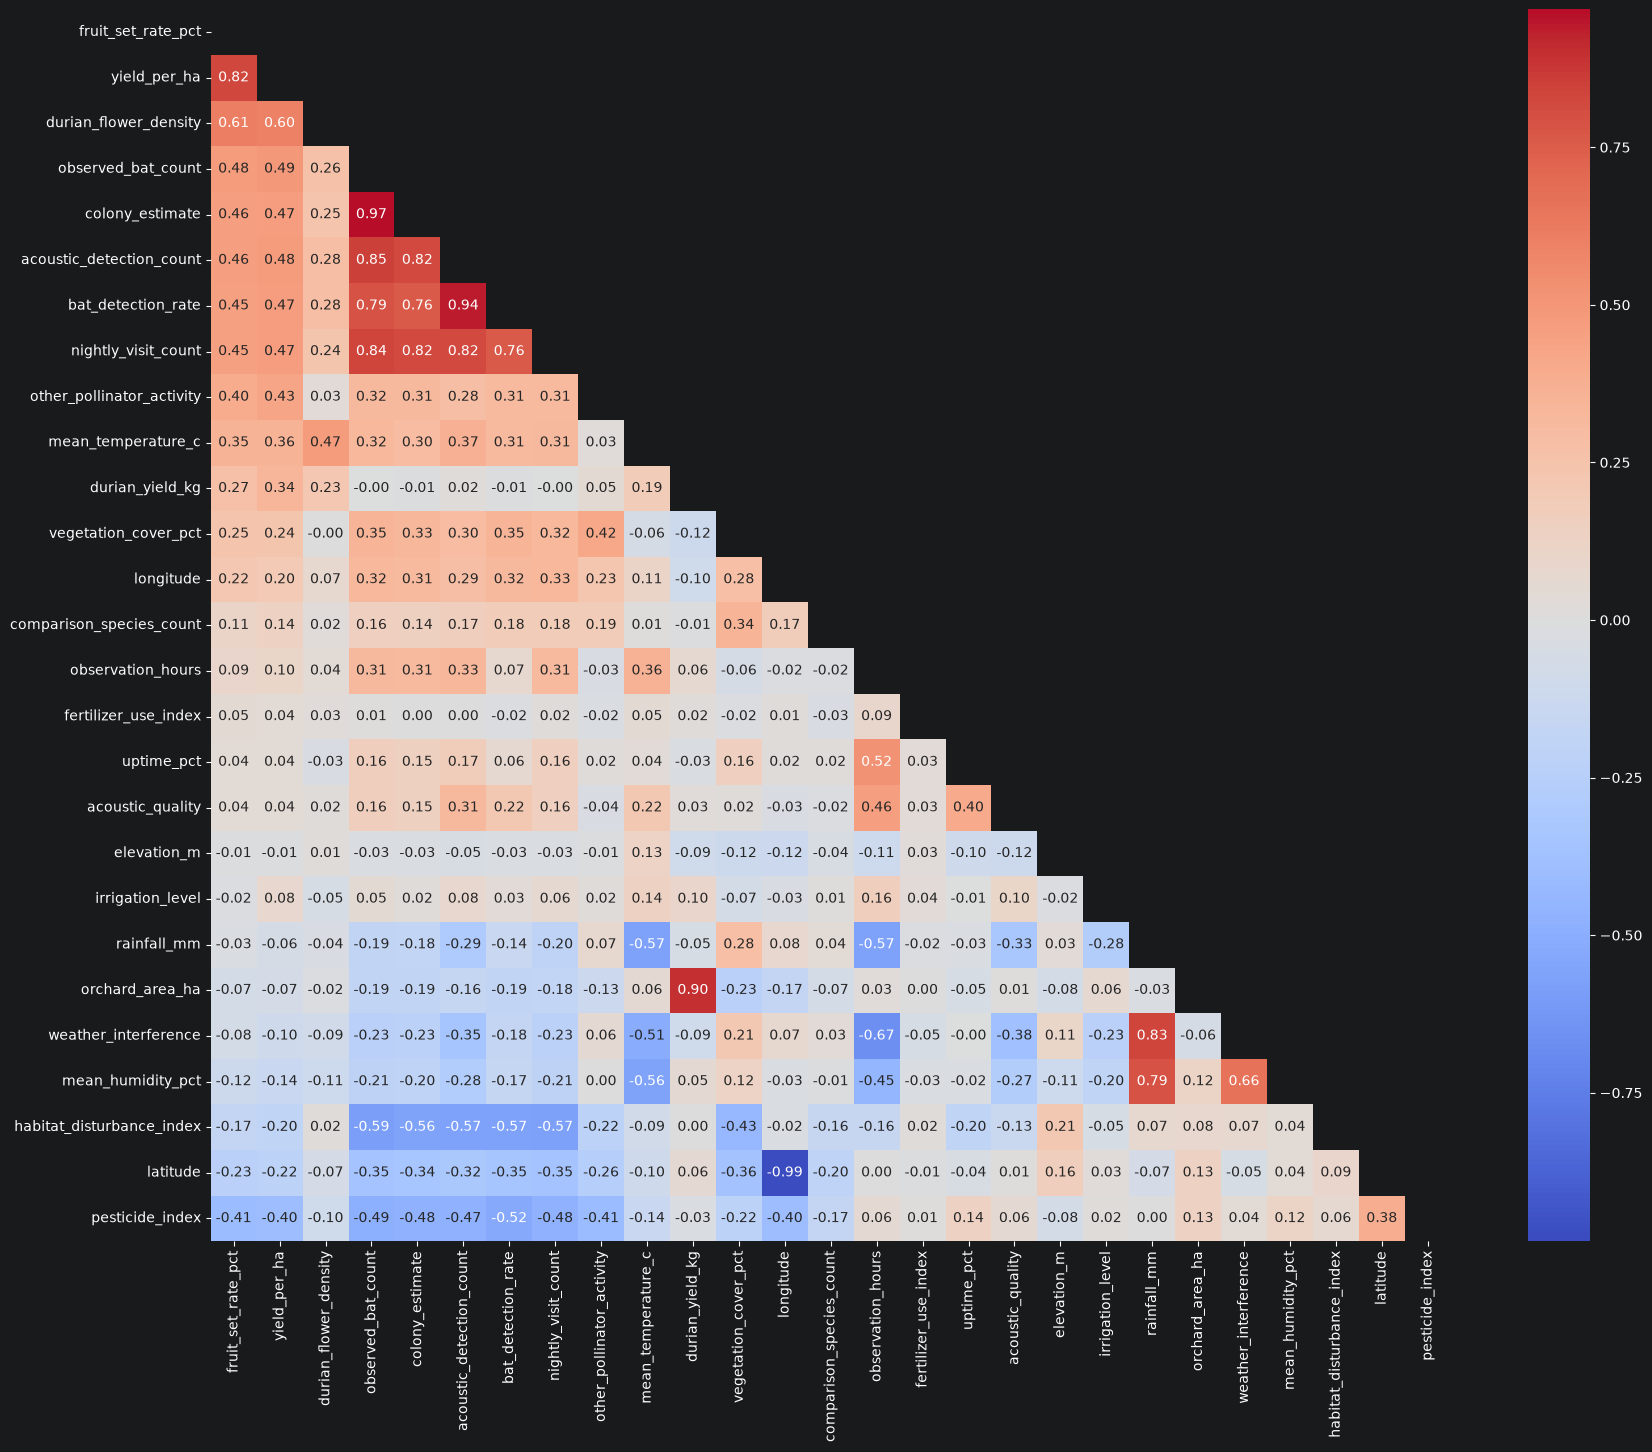

In [31]:
### Matrice de corrélation du panel
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

# Palette divergente : deux teintes opposées (rouge / bleu) séparées par un gris neutre à r = 0.
CORR_CMAP = LinearSegmentedColormap.from_list(
    "corr_div", ["#8e1f1e", "#e34948", "#f3b3b2", "#f0efec", "#9ec5f4", "#2a78d6", "#0d366b"])
INK, MUTED, SURFACE = "#0b0b0b", "#898781", "#fcfcfb"

# Variables qu'on a choisi d'étudier
GROUPS = {
    "Verger (orchard_surveys)": ["fruit_set_rate_pct", "yield_per_ha", "durian_yield_kg",
                                 "durian_flower_density", "orchard_area_ha",
                                 "other_pollinator_activity", "fertilizer_use_index", "irrigation_level"],
    "Environnement (environmental_monthly)": ['mean_temperature_c', 'rainfall_mm', 'mean_humidity_pct', 'vegetation_cover_pct',
                   'habitat_disturbance_index', 'pesticide_index'],
    "Chauves-souris (bat_surveys)": ["observed_bat_count", "colony_estimate", "acoustic_detection_count",
                                     "bat_detection_rate", "nightly_visit_count",
                                     "comparison_species_count", "observation_hours", "weather_interference"],
    "Matériel (monitoring_device_operations)": ['uptime_pct', 'acoustic_quality'],
    "Site (monitoring_sites)": ['latitude', 'longitude', 'elevation_m']
}
ORDER = [c for cols in GROUPS.values() for c in cols]

corr = panel[ORDER].corr()
order = corr["fruit_set_rate_pct"].sort_values(ascending=False).index
corr_ordered = corr.loc[order, order]
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(20, 16))
sns.heatmap(corr_ordered, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.show()

In [32]:
for c in corr.columns:
    corr_print = corr[corr[c].abs() >= 0.4]
    corr_print.drop(c, axis=0, inplace=True)
    print(c, " influences ",corr_print.index)

fruit_set_rate_pct  influences  Index(['yield_per_ha', 'durian_flower_density', 'pesticide_index',
       'observed_bat_count', 'colony_estimate', 'acoustic_detection_count',
       'bat_detection_rate', 'nightly_visit_count'],
      dtype='str')
yield_per_ha  influences  Index(['fruit_set_rate_pct', 'durian_flower_density',
       'other_pollinator_activity', 'observed_bat_count', 'colony_estimate',
       'acoustic_detection_count', 'bat_detection_rate',
       'nightly_visit_count'],
      dtype='str')
durian_yield_kg  influences  Index(['orchard_area_ha'], dtype='str')
durian_flower_density  influences  Index(['fruit_set_rate_pct', 'yield_per_ha', 'mean_temperature_c'], dtype='str')
orchard_area_ha  influences  Index(['durian_yield_kg'], dtype='str')
other_pollinator_activity  influences  Index(['yield_per_ha', 'vegetation_cover_pct', 'pesticide_index'], dtype='str')
fertilizer_use_index  influences  Index([], dtype='str')
irrigation_level  influences  Index([], dtype='str')
mean_t

## Observations
#### On observe des correlations logiques telles que la densité des fruits et le rendements par hectare avec les fleurs observées.
#### On observe aussi des correlations météorologiques telles que la température et la pluie avec le nb de fleurs
#### On observe que les chauves-souris sont corrélées avec plusieurs variables : des variables liées aux chauve-souris elles mêmes : disturbance, acoustic mais aussi les variables de rendements des fruits et rendements par hectare, la présence nocturne des chauve-souris également

## Conclusion
#### Les chauves-souris sont liées aux rendements fruitiers, plus particulièrement la nuit car elles sont nocturnes et se nourrissent des fleurs.

# Normalisation des données

In [33]:
# On utilise la fonction StandardScaler pour normaliser les données mais on pourrait penser à utiliser MinMax pour avoir de 0 à 1
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# bats_surveys
bats_cols = df_bats.select_dtypes(include="number").columns
normal_bats = df_bats.copy()
normal_bats[bats_cols] = scaler.fit_transform(df_bats[bats_cols])

# env_field_report
mon_dev_cols = df_monitor_dev.select_dtypes(include="number").columns
normal_monitor_dev = df_monitor_dev.copy()
normal_monitor_dev[mon_dev_cols] = scaler.fit_transform(df_monitor_dev[mon_dev_cols])

# env_monthly_clean
env_monthly_cols = df_env_monthly.select_dtypes(include="number").columns
normal_env_monthly = df_env_monthly.copy()
normal_env_monthly[env_monthly_cols] = scaler.fit_transform(df_env_monthly[env_monthly_cols])

# orchard_surveys
orchard_cols = df_orchard.select_dtypes(include="number").columns
normal_orchard = df_orchard.copy()
normal_orchard[orchard_cols] = scaler.fit_transform(df_orchard[orchard_cols])

In [34]:
print(normal_orchard.columns)

Index(['orchard_survey_id', 'site_code', 'survey_period', 'orchard_area_ha',
       'durian_flower_density', 'fruit_set_rate_pct', 'durian_yield_kg',
       'other_pollinator_activity', 'fertilizer_use_index', 'irrigation_level',
       'agricultural_disturbance_note',
       'agricultural_disturbance_note_  elevated  pesticide  application ',
       'agricultural_disturbance_note_  storm-related  flower  loss ',
       'agricultural_disturbance_note_elevated pesticide application',
       'agricultural_disturbance_note_storm-related flower loss', 'month'],
      dtype='str')


In [35]:
import os
os.environ["OMP_NUM_THREADS"] = "5"
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

num_cols = normal_orchard.select_dtypes(include="number").columns
X = normal_orchard[num_cols].dropna()
print(X.head())

X_tsne = TSNE(n_components=2, random_state=21).fit_transform(X)
X_tsne.shape

   orchard_area_ha  durian_flower_density  fruit_set_rate_pct  \
0        -1.129882              -1.021842           -1.811019   
1        -1.129882              -1.312550           -1.135541   
2        -1.129882              -0.359923            0.401417   
3        -1.129882               1.209899           -0.440484   
4        -1.129882               0.785018            0.802788   

   durian_yield_kg  other_pollinator_activity  fertilizer_use_index  \
0        -1.245869                  -0.452980             -1.045453   
1        -1.371066                   0.464815              0.548130   
2        -0.850001                   1.916214             -0.290598   
3        -1.171718                   0.849009             -1.446179   
4        -0.928572                   0.368767             -0.598131   

   irrigation_level  
0         -0.171770  
1          0.179151  
2          0.617803  
3         -0.402062  
4          0.080455  


(1248, 2)

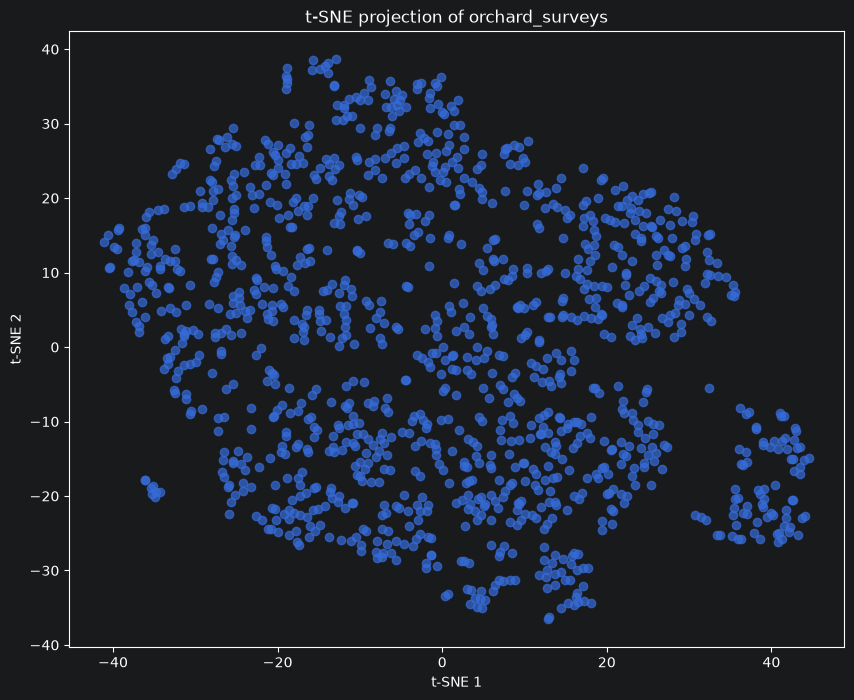

In [36]:
plt.figure(figsize=(10, 8))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], alpha=0.7)
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE projection of orchard_surveys")
plt.show()

C:\Users\Proprietaire\anaconda3\envs\DataMining\Lib\site-packages\sklearn\cluster\_kmeans.py:1424: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\Proprietaire\anaconda3\envs\DataMining\Lib\site-packages\sklearn\cluster\_kmeans.py:1424: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\Proprietaire\anaconda3\envs\DataMining\Lib\site-packages\sklearn\cluster\_kmeans.py:1424: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\Proprietaire\anaconda3\envs\DataMining\Lib\site-packages\s

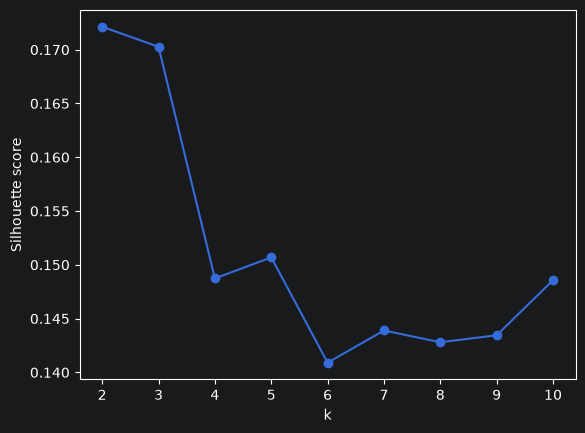

In [37]:
from sklearn.metrics import silhouette_score
#On cherche la silhouette max
silhouette_scores = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    silhouette_scores.append(silhouette_score(X, labels))

plt.plot(range(2, 11), silhouette_scores, marker="o")
plt.xlabel("k")
plt.ylabel("Silhouette score")
plt.show()

In [38]:
kmeans = KMeans(n_clusters=3, random_state=21, n_init=10)
clusters = kmeans.fit_predict(X)

C:\Users\Proprietaire\anaconda3\envs\DataMining\Lib\site-packages\sklearn\cluster\_kmeans.py:1424: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


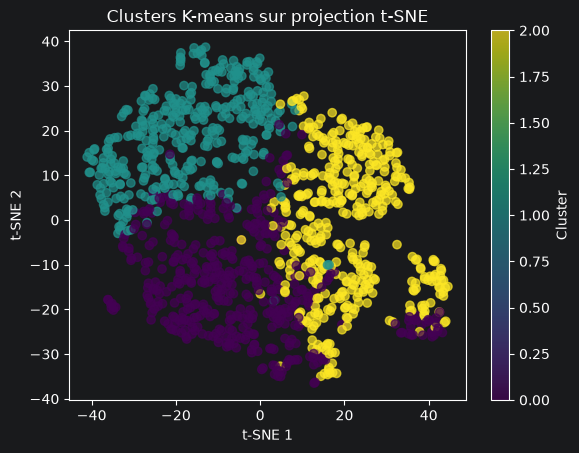

In [39]:
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=clusters, alpha=0.7)
plt.colorbar(label="Cluster")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("Clusters K-means sur projection t-SNE")
plt.show()

In [40]:
normal_orchard["cluster"] = clusters

In [41]:
print(normal_orchard[normal_orchard["cluster"] == 0].describe())
print("#"*100)
print(normal_orchard[normal_orchard["cluster"] == 1].describe())
print("#"*100)
print(normal_orchard[normal_orchard["cluster"] == 2].describe())

       orchard_area_ha  durian_flower_density  fruit_set_rate_pct  \
count       443.000000             443.000000          443.000000   
mean          0.329449              -0.713850           -0.849121   
std           0.689705               0.646829            0.792911   
min          -2.084136              -2.063917           -5.162272   
25%          -0.070185              -1.173904           -1.120857   
50%           0.467571              -0.807165           -0.734170   
75%           0.720633              -0.357687           -0.371957   
max           2.065024               1.648196            0.411206   

       durian_yield_kg  other_pollinator_activity  fertilizer_use_index  \
count       443.000000                 443.000000            443.000000   
mean         -0.067160                  -0.529443             -0.043965   
std           0.619816                   0.904924              0.989808   
min          -1.884422                  -3.366449             -2.527206   
25%

# Analyse
#### On observe un mini-cluster en bas à droite où on a des 'anomalies', peut etre des vergers qui ont des rendements anormalement bas.
#### Avec le print ci-dessous on peut voir que leur point commun est que 'durian_flower_density' est très bas par rapport au reste mais elles apparaissent à des dates completement différentes ce qui ne nous avance pas pour tirer une conclusion précise.

In [42]:
mask = (X_tsne[:, 0] < -30) & (X_tsne[:, 1] < -15)
indices = X.index[mask]  # X est le dataframe utilisé avant le fit_transform
for c in normal_orchard.columns:
    print(normal_orchard[c].loc[indices])

269     ORC-0000270
412     ORC-0000413
454     ORC-0000455
716     ORC-0000717
718     ORC-0000719
919     ORC-0000920
1060    ORC-0001061
1180    ORC-0001181
Name: orchard_survey_id, dtype: str
269     AVL-TRP
412     AVL-GRB
454     AVL-GRB
716     AVL-YAU
718     AVL-YAU
919     AVL-NMQ
1060    TMB-BRC
1180    TMB-HQL
Name: site_code, dtype: str
269     2021-12-01
412     2020-11-01
454     2024-05-01
716     2020-03-01
718     2020-05-01
919     2024-02-01
1060    2022-11-01
1180    2019-11-01
Name: survey_period, dtype: str
269     0.483388
412     0.467571
454     0.467571
716    -2.084136
718    -2.084136
919    -0.750289
1060   -1.045528
1180   -0.070185
Name: orchard_area_ha, dtype: float64
269    -0.306254
412    -0.614851
454     1.133867
716    -0.060270
718     1.080198
919    -1.254408
1060   -1.308077
1180   -0.020018
Name: durian_flower_density, dtype: float64
269    -5.152384
412    -5.154832
454    -5.154244
716    -5.153070
718    -5.149741
919    -5.162272
1060   -